In [25]:
import requests
import re
import nltk
import spacy
import matplotlib.pyplot as plt
import pandas as pd

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk import pos_tag, ne_chunk

from wordcloud import WordCloud

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

In [2]:
# Tokenizers
nltk.download("punkt")
nltk.download("punkt_tab")

# Stopwords
nltk.download("stopwords")

# POS tagger
nltk.download("averaged_perceptron_tagger")
nltk.download("averaged_perceptron_tagger_eng")

# Named entity recognition resources
nltk.download("maxent_ne_chunker")
nltk.download("maxent_ne_chunker_tab")
nltk.download("words")

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/gabrielroisenbergrodrigues/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/gabrielroisenbergrodrigues/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/gabrielroisenbergrodrigues/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/gabrielroisenbergrodrigues/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/gabrielroisenbergrodrigues/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /Users/gab

True

In [3]:
# Load the small English spaCy model
nlp = spacy.load("en_core_web_sm")

# Increase max_length because the books are long
nlp.max_length = 2_000_000

In [ ]:
# Define URLs and book titles
urls = [
    "https://www.gutenberg.org/cache/epub/11/pg11.txt",
    "https://www.gutenberg.org/cache/epub/12/pg12.txt",
    "https://www.gutenberg.org/cache/epub/29042/pg29042.txt"
]

book_titles = [
    "Alice’s Adventures in Wonderland",
    "Through the Looking-Glass",
    "A Tangled Tale"
]

In [5]:
def remove_gutenberg_header_footer(text):
    """
    Removes Project Gutenberg header and footer.

    Gutenberg texts usually mark the beginning and end of the actual book with:

    *** START OF THE PROJECT GUTENBERG EBOOK ... ***
    *** END OF THE PROJECT GUTENBERG EBOOK ... ***

    We use regex to find those markers and keep only the book content.
    """

    # Find the START marker
    start_match = re.search(r"\*\*\* START OF.*?\*\*\*", text, re.IGNORECASE)

    # Find the END marker
    end_match = re.search(r"\*\*\* END OF.*?\*\*\*", text, re.IGNORECASE)

    # If START marker exists, remove everything before it
    if start_match:
        text = text[start_match.end():]

    # If END marker exists, remove everything after it
    if end_match:
        text = text[:end_match.start()]

    return text

In [6]:
def clean_text_for_frequency(text):
    """
    Cleans text for frequency-based analysis.

    This version:
    - keeps only letters and spaces
    - lowercases everything
    - removes extra whitespace

    This is good for BoW, TF-IDF, word clouds, stemming, and lemmatization.
    """

    # Replace anything that is not a letter or whitespace with a space
    text = re.sub(r"[^A-Za-z\s]", " ", text)

    # Replace multiple spaces/newlines/tabs with one space
    text = re.sub(r"\s+", " ", text)

    # Lowercase everything
    text = text.lower()

    # Remove leading/trailing spaces
    text = text.strip()

    return text


def clean_text_for_linguistic_analysis(text):
    """
    Cleans text for POS tagging and Named Entity Recognition.

    This version:
    - keeps capitalization
    - keeps punctuation
    - only normalizes whitespace

    This is important because NER depends heavily on capitalization.
    For example, 'Alice' is easier to recognize as a name than 'alice'.
    """

    # Replace multiple spaces/newlines/tabs with one space
    text = re.sub(r"\s+", " ", text)

    # Remove leading/trailing spaces
    text = text.strip()

    return text

In [7]:
def load_texts(urls):
    """
    Receives a list of URLs.

    For each URL:
    1. Downloads the text.
    2. Removes Gutenberg header/footer.
    3. Creates a frequency-cleaned version.
    4. Creates a linguistic-analysis version.

    Returns:
    - frequency_corpus: lowercase cleaned texts
    - linguistic_corpus: capitalization-preserving texts
    """

    frequency_corpus = []
    linguistic_corpus = []

    for url in urls:
        # Download text from URL
        response = requests.get(url)

        # Raise an error if the request failed
        response.raise_for_status()

        # Original text from the webpage
        raw_text = response.text

        # Remove Project Gutenberg metadata
        main_text = remove_gutenberg_header_footer(raw_text)

        # Clean version for BoW / TF-IDF / word cloud
        frequency_text = clean_text_for_frequency(main_text)

        # Clean version for POS / NER
        linguistic_text = clean_text_for_linguistic_analysis(main_text)

        # Add both versions to their corpora
        frequency_corpus.append(frequency_text)
        linguistic_corpus.append(linguistic_text)

    return frequency_corpus, linguistic_corpus

In [8]:
frequency_corpus, linguistic_corpus = load_texts(urls)

print("Number of books in frequency corpus:", len(frequency_corpus))
print("Number of books in linguistic corpus:", len(linguistic_corpus))

Number of books in frequency corpus: 3
Number of books in linguistic corpus: 3


In [9]:
# Print the first 200 characters of each text
for title, text in zip(book_titles, frequency_corpus):
    print("=" * 80)
    print(title)
    print("=" * 80)
    print(text[:200])
    print()

Alice’s Adventures in Wonderland
illustration alice s adventures in wonderland by lewis carroll the millennium fulcrum edition contents chapter i down the rabbit hole chapter ii the pool of tears chapter iii a caucus race and a long 

Through the Looking-Glass
illustration through the looking glass and what alice found there by lewis carroll the millennium fulcrum edition dramatis person as arranged before commencement of game white red pieces pawns pawns p

A Tangled Tale
produced by chris curnow carla foust lindy walsh and the online distributed proofreading team at https www pgdp net music transcribed by linda cantoni transcriber s note minor punctuation errors have 



In [10]:
# Tokenize the text and print first 150 tokens
tokenized_books = []

for text in frequency_corpus:
    tokens = word_tokenize(text)
    tokenized_books.append(tokens)

for title, tokens in zip(book_titles, tokenized_books):
    print("=" * 80)
    print(title)
    print("=" * 80)
    print(tokens[:150])
    print()

Alice’s Adventures in Wonderland
['illustration', 'alice', 's', 'adventures', 'in', 'wonderland', 'by', 'lewis', 'carroll', 'the', 'millennium', 'fulcrum', 'edition', 'contents', 'chapter', 'i', 'down', 'the', 'rabbit', 'hole', 'chapter', 'ii', 'the', 'pool', 'of', 'tears', 'chapter', 'iii', 'a', 'caucus', 'race', 'and', 'a', 'long', 'tale', 'chapter', 'iv', 'the', 'rabbit', 'sends', 'in', 'a', 'little', 'bill', 'chapter', 'v', 'advice', 'from', 'a', 'caterpillar', 'chapter', 'vi', 'pig', 'and', 'pepper', 'chapter', 'vii', 'a', 'mad', 'tea', 'party', 'chapter', 'viii', 'the', 'queen', 's', 'croquet', 'ground', 'chapter', 'ix', 'the', 'mock', 'turtle', 's', 'story', 'chapter', 'x', 'the', 'lobster', 'quadrille', 'chapter', 'xi', 'who', 'stole', 'the', 'tarts', 'chapter', 'xii', 'alice', 's', 'evidence', 'chapter', 'i', 'down', 'the', 'rabbit', 'hole', 'alice', 'was', 'beginning', 'to', 'get', 'very', 'tired', 'of', 'sitting', 'by', 'her', 'sister', 'on', 'the', 'bank', 'and', 'of', 'hav

In [11]:
# Remove stopwords
# Load English stopwords from NLTK
stop_words = set(stopwords.words("english"))

tokens_no_stopwords = []

for tokens in tokenized_books:
    # Keep only tokens that are not stopwords
    filtered_tokens = [token for token in tokens if token not in stop_words]
    tokens_no_stopwords.append(filtered_tokens)

In [13]:
print("Before stopword removal:")
print()

for title, tokens in zip(book_titles, tokenized_books):
    print(title)
    print("i:", tokens.count("i"))
    print("me:", tokens.count("me"))
    print("my:", tokens.count("my"))
    print("myself:", tokens.count("myself"))
    print("we:", tokens.count("we"))
    print("our:", tokens.count("our"))
    print()

print("After stopword removal:")
print()

for title, tokens in zip(book_titles, tokens_no_stopwords):
    print(title)
    print("i:", tokens.count("i"))
    print("me:", tokens.count("me"))
    print("my:", tokens.count("my"))
    print("myself:", tokens.count("myself"))
    print("we:", tokens.count("we"))
    print("our:", tokens.count("our"))
    print()

Before stopword removal:

Alice’s Adventures in Wonderland
i: 546
me: 68
my: 58
myself: 7
we: 34
our: 8

Through the Looking-Glass
i: 662
me: 96
my: 77
myself: 7
we: 54
our: 11

A Tangled Tale
i: 395
me: 53
my: 75
myself: 4
we: 124
our: 27

After stopword removal:

Alice’s Adventures in Wonderland
i: 0
me: 0
my: 0
myself: 0
we: 0
our: 0

Through the Looking-Glass
i: 0
me: 0
my: 0
myself: 0
we: 0
our: 0

A Tangled Tale
i: 0
me: 0
my: 0
myself: 0
we: 0
our: 0



In [14]:
# Stem tokens with PorterStemmer
stemmer = PorterStemmer()

stemmed_books = []

for tokens in tokens_no_stopwords:
    stemmed_tokens = [stemmer.stem(token) for token in tokens]
    stemmed_books.append(stemmed_tokens)

# Print the first 50 stemmed tokens
for title, stemmed_tokens in zip(book_titles, stemmed_books):
    print("=" * 80)
    print(title)
    print("=" * 80)
    print(stemmed_tokens[:50])
    print()

Alice’s Adventures in Wonderland
['illustr', 'alic', 'adventur', 'wonderland', 'lewi', 'carrol', 'millennium', 'fulcrum', 'edit', 'content', 'chapter', 'rabbit', 'hole', 'chapter', 'ii', 'pool', 'tear', 'chapter', 'iii', 'caucu', 'race', 'long', 'tale', 'chapter', 'iv', 'rabbit', 'send', 'littl', 'bill', 'chapter', 'v', 'advic', 'caterpillar', 'chapter', 'vi', 'pig', 'pepper', 'chapter', 'vii', 'mad', 'tea', 'parti', 'chapter', 'viii', 'queen', 'croquet', 'ground', 'chapter', 'ix', 'mock']

Through the Looking-Glass
['illustr', 'look', 'glass', 'alic', 'found', 'lewi', 'carrol', 'millennium', 'fulcrum', 'edit', 'dramati', 'person', 'arrang', 'commenc', 'game', 'white', 'red', 'piec', 'pawn', 'pawn', 'piec', 'tweedlede', 'daisi', 'daisi', 'humpti', 'dumpti', 'unicorn', 'haigha', 'messeng', 'carpent', 'sheep', 'oyster', 'oyster', 'walru', 'w', 'queen', 'lili', 'tiger', 'lili', 'r', 'queen', 'w', 'king', 'fawn', 'rose', 'r', 'king', 'age', 'man', 'oyster']

A Tangled Tale
['produc', 'chri

In [16]:
# Lemmatize tokens with spaCy

lemmatized_books = []

for text in frequency_corpus:
    # Process text with spaCy
    doc = nlp(text)

    # Keep only alphabetic tokens and remove stopwords
    lemmas = [
        token.lemma_
        for token in doc
        if token.is_alpha and token.lemma_ not in stop_words
    ]

    lemmatized_books.append(lemmas)

for title, lemmas in zip(book_titles, lemmatized_books):
    print("=" * 80)
    print(title)
    print("=" * 80)
    print(lemmas[:50])
    print()

Alice’s Adventures in Wonderland
['illustration', 'alice', 'adventure', 'wonderland', 'lewis', 'carroll', 'millennium', 'fulcrum', 'edition', 'content', 'chapter', 'I', 'rabbit', 'hole', 'chapter', 'ii', 'pool', 'tears', 'chapter', 'iii', 'caucus', 'race', 'long', 'tale', 'chapter', 'iv', 'rabbit', 'send', 'little', 'bill', 'chapter', 'v', 'advice', 'caterpillar', 'chapter', 'vi', 'pig', 'pepper', 'chapter', 'vii', 'mad', 'tea', 'party', 'chapter', 'viii', 'queen', 'croquet', 'ground', 'chapter', 'ix']

Through the Looking-Glass
['illustration', 'look', 'glass', 'alice', 'find', 'lewis', 'carroll', 'millennium', 'fulcrum', 'edition', 'dramatis', 'person', 'arrange', 'commencement', 'game', 'white', 'red', 'piece', 'pawn', 'pawn', 'piece', 'tweedledee', 'daisy', 'daisy', 'humpty', 'dumpty', 'unicorn', 'haigha', 'messenger', 'carpenter', 'sheep', 'oyster', 'oyster', 'walrus', 'w', 'queen', 'lily', 'tiger', 'lily', 'r', 'queen', 'w', 'king', 'fawn', 'rise', 'r', 'king', 'aged', 'man', 'oy

In [17]:
for title, stems, lemmas in zip(book_titles, stemmed_books, lemmatized_books):
    print("=" * 80)
    print(title)
    print("=" * 80)
    print(f"{'Stemmed':20} {'Lemmatized'}")
    print("-" * 40)

    for stem, lemma in zip(stems[:50], lemmas[:50]):
        print(f"{stem:20} {lemma}")

    print()

Alice’s Adventures in Wonderland
Stemmed              Lemmatized
----------------------------------------
illustr              illustration
alic                 alice
adventur             adventure
wonderland           wonderland
lewi                 lewis
carrol               carroll
millennium           millennium
fulcrum              fulcrum
edit                 edition
content              content
chapter              chapter
rabbit               I
hole                 rabbit
chapter              hole
ii                   chapter
pool                 ii
tear                 pool
chapter              tears
iii                  chapter
caucu                iii
race                 caucus
long                 race
tale                 long
chapter              tale
iv                   chapter
rabbit               iv
send                 rabbit
littl                send
bill                 little
chapter              bill
v                    chapter
advic                v
caterpilla

**Observation**: Stemming and lemmatization both reduce words to simpler forms, but they work differently.

Stemming uses rough rules to cut off word endings. It is fast, but it can produce forms that are not real English words. For example, “adventures” may become “adventur”.

Lemmatization uses vocabulary and grammatical information to return the dictionary form of a word. For example, “was” can become “be”, and “children” can become “child”.

The lemmatized tokens are usually easier to interpret because they remain real words. For this exercise, lemmatized tokens are better for BoW, word clouds, and TF-IDF because they group related word forms while keeping the output readable.

In [18]:
# POS tagging with NLTK

# Tokenize the capitalization-preserving corpus
linguistic_tokenized_books = []

for text in linguistic_corpus:
    tokens = word_tokenize(text)
    linguistic_tokenized_books.append(tokens)

# POS tag each book
pos_tagged_books = []

for tokens in linguistic_tokenized_books:
    tagged_tokens = pos_tag(tokens)
    pos_tagged_books.append(tagged_tokens)

# Print first 100 POS-tagged tokens
for title, tagged_tokens in zip(book_titles, pos_tagged_books):
    print("=" * 80)
    print(title)
    print("=" * 80)
    print(tagged_tokens[:100])
    print()

Alice’s Adventures in Wonderland
[('[', 'JJ'), ('Illustration', 'NNP'), (']', 'NNP'), ('Alice', 'NNP'), ('’', 'NNP'), ('s', 'NN'), ('Adventures', 'NNP'), ('in', 'IN'), ('Wonderland', 'NNP'), ('by', 'IN'), ('Lewis', 'NNP'), ('Carroll', 'NNP'), ('THE', 'NNP'), ('MILLENNIUM', 'NNP'), ('FULCRUM', 'NNP'), ('EDITION', 'NNP'), ('3.0', 'CD'), ('Contents', 'NNP'), ('CHAPTER', 'NN'), ('I', 'PRP'), ('.', '.'), ('Down', 'RP'), ('the', 'DT'), ('Rabbit-Hole', 'JJ'), ('CHAPTER', 'NNP'), ('II', 'NNP'), ('.', '.'), ('The', 'DT'), ('Pool', 'NNP'), ('of', 'IN'), ('Tears', 'NNP'), ('CHAPTER', 'NNP'), ('III', 'NNP'), ('.', '.'), ('A', 'DT'), ('Caucus-Race', 'NN'), ('and', 'CC'), ('a', 'DT'), ('Long', 'JJ'), ('Tale', 'NNP'), ('CHAPTER', 'NNP'), ('IV', 'NNP'), ('.', '.'), ('The', 'DT'), ('Rabbit', 'NNP'), ('Sends', 'NNPS'), ('in', 'IN'), ('a', 'DT'), ('Little', 'JJ'), ('Bill', 'NNP'), ('CHAPTER', 'NNP'), ('V.', 'NNP'), ('Advice', 'NNP'), ('from', 'IN'), ('a', 'DT'), ('Caterpillar', 'NNP'), ('CHAPTER', 'NNP')

In [20]:
# Named Entity Recognition with NLTK
entity_trees = []

for tagged_tokens in pos_tagged_books:
    # Use only the first 5000 tagged tokens to keep processing manageable.
    # You can remove [:5000] if you want the whole book, but it may be slower.
    tree = ne_chunk(tagged_tokens[:5000])
    entity_trees.append(tree)

In [21]:
# extract only named entities

def extract_named_entities(tree):
    """
    Extracts named entities from an NLTK ne_chunk tree.

    ne_chunk returns a tree containing:
    - normal word/tag tuples, like ('Rabbit', 'NNP')
    - named entity subtrees, like Tree('PERSON', [('Alice', 'NNP')])

    This function keeps only the named entity subtrees.
    """

    entities = []

    for subtree in tree:
        # Named entity subtrees have a label() method.
        # Normal tuples do not.
        if hasattr(subtree, "label"):

            # Get the words inside the entity.
            # Example:
            # Tree('PERSON', [('Lewis', 'NNP'), ('Carroll', 'NNP')])
            # becomes "Lewis Carroll"
            entity_name = " ".join(word for word, tag in subtree.leaves())

            # Get the entity type.
            # Examples: PERSON, ORGANIZATION, GPE
            entity_label = subtree.label()

            # Store entity as a tuple
            entities.append((entity_name, entity_label))

    return entities

named_entities_books = []

for tree in entity_trees:
    entities = extract_named_entities(tree)
    named_entities_books.append(entities)

# Print first 30 entities per book
for title, entities in zip(book_titles, named_entities_books):
    print("=" * 80)
    print(title)
    print("=" * 80)
    print(entities[:30])
    print()

Alice’s Adventures in Wonderland
[('Wonderland', 'GPE'), ('Lewis Carroll THE', 'PERSON'), ('MILLENNIUM', 'ORGANIZATION'), ('Pool', 'ORGANIZATION'), ('Tears', 'PERSON'), ('Long Tale', 'ORGANIZATION'), ('Rabbit Sends', 'ORGANIZATION'), ('Bill', 'PERSON'), ('Caterpillar', 'ORGANIZATION'), ('Pig', 'PERSON'), ('Pepper', 'PERSON'), ('VIII', 'ORGANIZATION'), ('Queen', 'ORGANIZATION'), ('Mock Turtle', 'ORGANIZATION'), ('Story', 'PERSON'), ('Lobster Quadrille', 'ORGANIZATION'), ('Evidence', 'PERSON'), ('Alice', 'PERSON'), ('White Rabbit', 'FACILITY'), ('Rabbit', 'ORGANIZATION'), ('Rabbit', 'ORGANIZATION'), ('Alice', 'PERSON'), ('Alice', 'PERSON'), ('ORANGE', 'ORGANIZATION'), ('Which', 'PERSON'), ('Alice', 'PERSON'), ('Latitude', 'PERSON'), ('Alice', 'ORGANIZATION'), ('Latitude', 'PERSON'), ('Longitude', 'ORGANIZATION')]

Through the Looking-Glass
[('THE', 'ORGANIZATION'), ('Alice', 'PERSON'), ('Lewis Carroll', 'PERSON'), ('Millennium Fulcrum', 'FACILITY'), ('DRAMATIS', 'ORGANIZATION'), ('_As', 

In [22]:
# Convert lemmatized tokens back to strings

lemmatized_texts = []

for lemmas in lemmatized_books:
    text = " ".join(lemmas)
    lemmatized_texts.append(text)

for title, text in zip(book_titles, lemmatized_texts):
    print("=" * 80)
    print(title)
    print("=" * 80)
    print(text[:300])
    print()

Alice’s Adventures in Wonderland
illustration alice adventure wonderland lewis carroll millennium fulcrum edition content chapter I rabbit hole chapter ii pool tears chapter iii caucus race long tale chapter iv rabbit send little bill chapter v advice caterpillar chapter vi pig pepper chapter vii mad tea party chapter viii queen cr

Through the Looking-Glass
illustration look glass alice find lewis carroll millennium fulcrum edition dramatis person arrange commencement game white red piece pawn pawn piece tweedledee daisy daisy humpty dumpty unicorn haigha messenger carpenter sheep oyster oyster walrus w queen lily tiger lily r queen w king fawn rise r 

A Tangled Tale
produce chris curnow carla foust lindy walsh online distribute proofreading team https www pgdp net music transcribe linda cantoni transcriber note minor punctuation error change without notice printer error change list end inconsistency original version square root symbol indicate sqrt superscript 



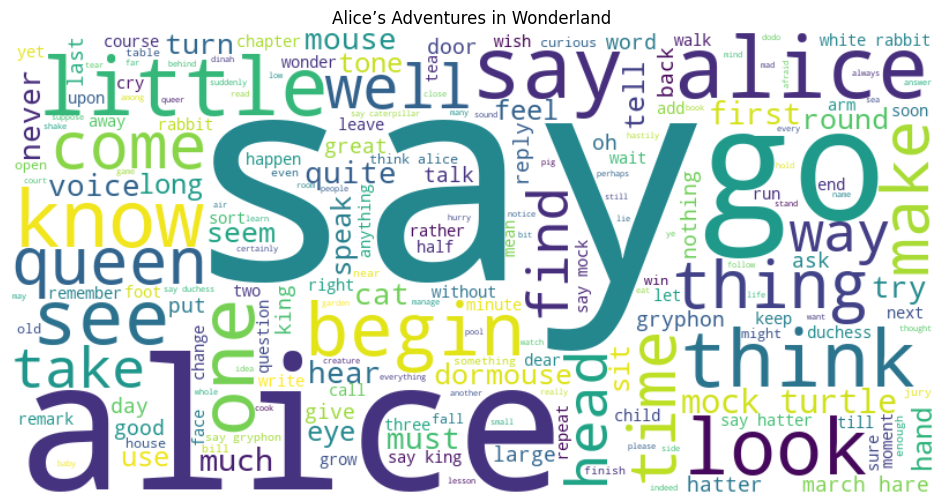

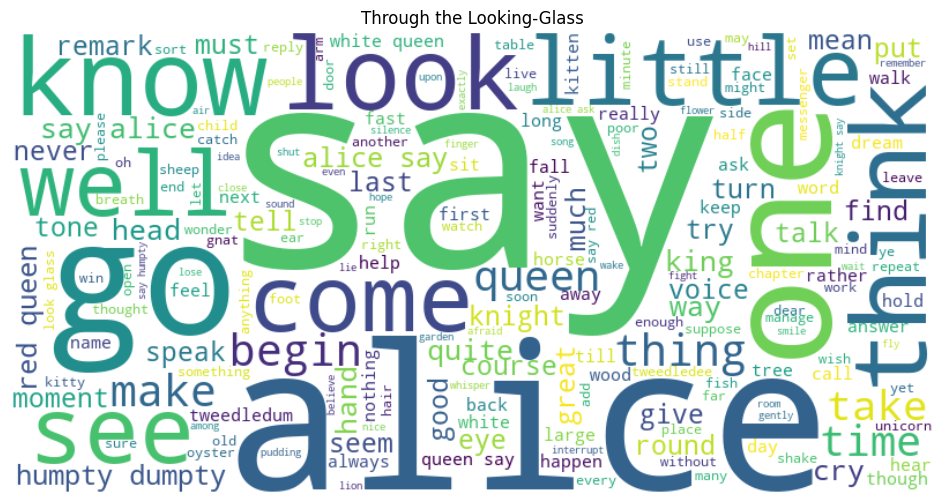

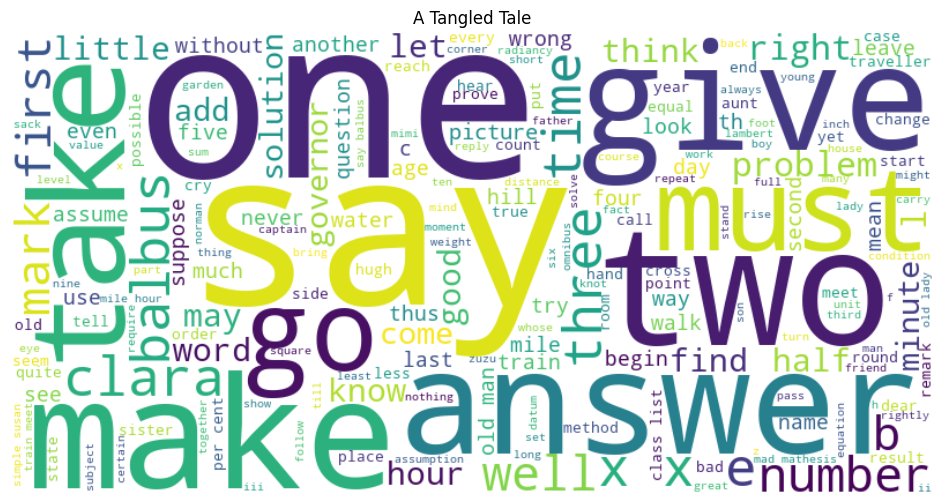

In [23]:
# Word cloud for each book

for title, text in zip(book_titles, lemmatized_texts):
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color="white"
    ).generate(text)

    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(title)
    plt.show()

In [24]:
# BoW with CountVectorizer

count_vectorizer = CountVectorizer()

bow_matrix = count_vectorizer.fit_transform(lemmatized_texts)

feature_names = count_vectorizer.get_feature_names_out()

bow_matrix.shape

(3, 4561)

In [26]:
# Convert BoW matrix to DataFrame

bow_df = pd.DataFrame(
    bow_matrix.toarray(),
    columns=feature_names,
    index=book_titles
)

bow_df.head()

,ab,abandon,abate,abide,able,abroad,abruptness,absence,absent,absolutely,...,young,youth,ys,ysmim,zealand,zero,zigzag,zimmermann,zoedone,zuzu
Alice’s Adventures in Wonderland,0,0,0,1,1,0,0,1,0,0,...,5,6,0,0,1,0,1,0,0,0
Through the Looking-Glass,0,0,0,0,6,0,0,0,0,0,...,6,0,0,1,0,0,0,0,0,0
A Tangled Tale,2,1,1,0,0,1,1,0,1,3,...,21,6,3,0,0,2,0,1,5,14


In [27]:
# Print five most frequent words in each book

for title in book_titles:
    print("=" * 80)
    print(title)
    print("=" * 80)

    top_5 = bow_df.loc[title].sort_values(ascending=False).head(5)

    print(top_5)
    print()

Alice’s Adventures in Wonderland
say       529
alice     400
go        180
little    129
think     123
Name: Alice’s Adventures in Wonderland, dtype: int64

Through the Looking-Glass
say      544
alice    468
queen    201
go       186
look     158
Name: Through the Looking-Glass, dtype: int64

A Tangled Tale
say       234
one       216
two       108
answer    102
make       94
Name: A Tangled Tale, dtype: int64



In [28]:
#  Print BoW sparse matrix

print(bow_matrix)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 7055 stored elements and shape (3, 4561)>
  Coords	Values
  (0, 1993)	1
  (0, 115)	400
  (0, 70)	8
  (0, 4490)	4
  (0, 2290)	1
  (0, 576)	1
  (0, 2513)	1
  (0, 1634)	1
  (0, 1254)	6
  (0, 836)	2
  (0, 617)	24
  (0, 3167)	54
  (0, 1912)	6
  (0, 1988)	2
  (0, 2990)	12
  (0, 3953)	1
  (0, 1989)	2
  (0, 592)	4
  (0, 3168)	7
  (0, 2351)	38
  (0, 3928)	6
  (0, 2122)	2
  (0, 3480)	7
  (0, 2328)	129
  (0, 388)	18
  :	:
  (2, 4558)	1
  (2, 2921)	1
  (2, 3359)	1
  (2, 3281)	2
  (2, 750)	1
  (2, 2909)	1
  (2, 1965)	1
  (2, 2583)	2
  (2, 4088)	1
  (2, 2492)	1
  (2, 2)	1
  (2, 1107)	2
  (2, 2862)	1
  (2, 3102)	1
  (2, 3283)	1
  (2, 1239)	1
  (2, 1765)	1
  (2, 2260)	1
  (2, 1609)	1
  (2, 2491)	1
  (2, 1839)	1
  (2, 2819)	1
  (2, 2404)	1
  (2, 778)	1
  (2, 894)	1


In [29]:
# Print BoW in a more readable way

for doc_index, word_index in zip(*bow_matrix.nonzero()):
    count = bow_matrix[doc_index, word_index]
    word = feature_names[word_index]

    print(f"Document number: {doc_index}")
    print(f"Book title: {book_titles[doc_index]}")
    print(f"Word index: {word_index}")
    print(f"Word: {word}")
    print(f"Count: {count}")
    print("-" * 40)

    # Stop early so the output does not become enormous
    if doc_index >= 1:
        break

Document number: 0
Book title: Alice’s Adventures in Wonderland
Word index: 1993
Word: illustration
Count: 1
----------------------------------------
Document number: 0
Book title: Alice’s Adventures in Wonderland
Word index: 115
Word: alice
Count: 400
----------------------------------------
Document number: 0
Book title: Alice’s Adventures in Wonderland
Word index: 70
Word: adventure
Count: 8
----------------------------------------
Document number: 0
Book title: Alice’s Adventures in Wonderland
Word index: 4490
Word: wonderland
Count: 4
----------------------------------------
Document number: 0
Book title: Alice’s Adventures in Wonderland
Word index: 2290
Word: lewis
Count: 1
----------------------------------------
Document number: 0
Book title: Alice’s Adventures in Wonderland
Word index: 576
Word: carroll
Count: 1
----------------------------------------
Document number: 0
Book title: Alice’s Adventures in Wonderland
Word index: 2513
Word: millennium
Count: 1
-------------------

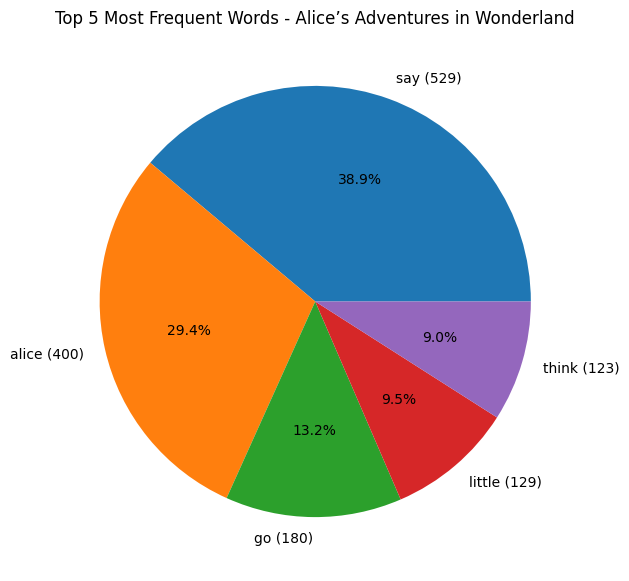

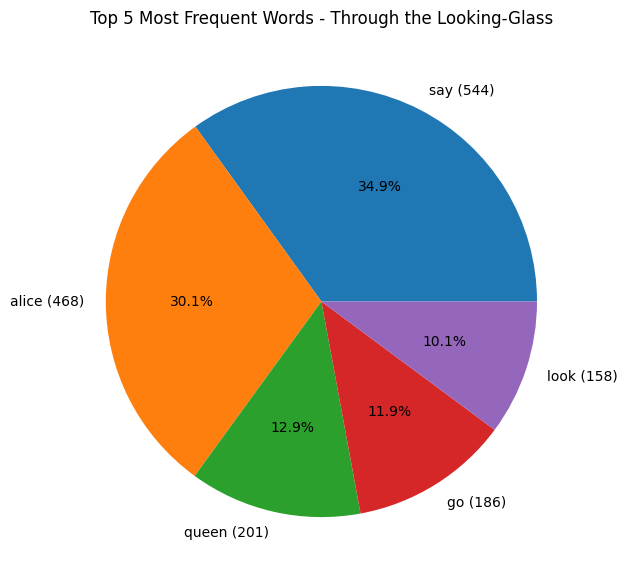

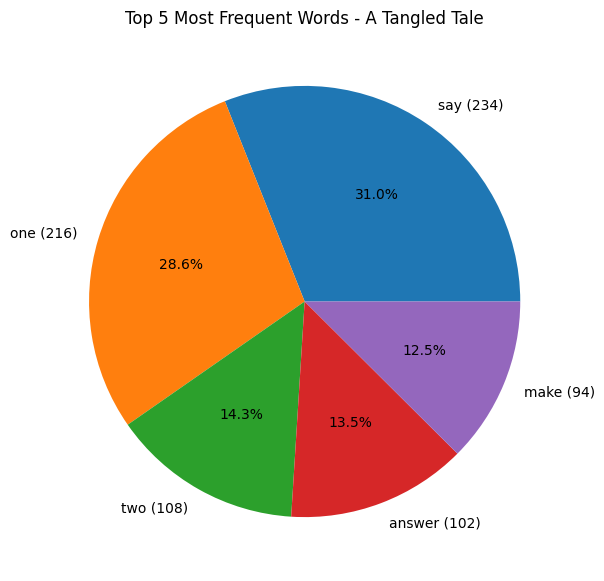

In [30]:
# Pie plot of the most frequent words

for title in book_titles:
    top_5 = bow_df.loc[title].sort_values(ascending=False).head(5)

    labels = [f"{word} ({freq})" for word, freq in top_5.items()]

    plt.figure(figsize=(7, 7))
    plt.pie(top_5.values, labels=labels, autopct="%1.1f%%")
    plt.title(f"Top 5 Most Frequent Words - {title}")
    plt.show()

**Observation**: The most frequent words are partly informative, but many are expected. In a book about Alice, words such as “alice” are naturally very frequent. Common narrative verbs such as “say”, “go”, or “think” may also appear often because they are common in storytelling.

This means that raw frequency does not always tell us which words are distinctive or meaningful. It often tells us which words are repeated the most.

The BoW results are useful for seeing dominant words, but they are limited because they treat all words as equally important.

In [33]:
# TF-IDF vectorizer

tfidf_vectorizer = TfidfVectorizer(
    min_df=1,
    max_df=2
)

tfidf_matrix = tfidf_vectorizer.fit_transform(lemmatized_texts)

tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()


In [34]:
# Convert TF-IDF matrix to DataFrame
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_feature_names,
    index=book_titles
)

tfidf_df.head()

,ab,abandon,abate,abide,able,abroad,abruptness,absence,absent,absolutely,...,york,youth,ys,ysmim,zealand,zero,zigzag,zimmermann,zoedone,zuzu
Alice’s Adventures in Wonderland,0.000000,0.000000,0.000000,0.006049,0.004601,0.000000,0.000000,0.006049,0.000000,0.000000,...,0.000000,0.027603,0.000000,0.000000,0.006049,0.000000,0.006049,0.000000,0.000000,0.000000
Through the Looking-Glass,0.000000,0.000000,0.000000,0.000000,0.028799,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.006311,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
A Tangled Tale,0.008857,0.004429,0.004429,0.000000,0.000000,0.004429,0.004429,0.000000,0.004429,0.013286,...,0.004429,0.020208,0.013286,0.000000,0.000000,0.008857,0.000000,0.004429,0.022143,0.061999


In [35]:
# Top 5 TF-IDF words per book
for title in book_titles:
    print("=" * 80)
    print(title)
    print("=" * 80)

    top_5_tfidf = tfidf_df.loc[title].sort_values(ascending=False).head(5)

    print(top_5_tfidf)
    print()

Alice’s Adventures in Wonderland
gryphon    0.332701
rabbit     0.326652
turtle     0.285232
mock       0.262229
hatter     0.262229
Name: Alice’s Adventures in Wonderland, dtype: float64

Through the Looking-Glass
dumpty        0.353426
humpty        0.353426
knight        0.292789
tweedledum    0.233513
tweedledee    0.183024
Name: Through the Looking-Glass, dtype: float64

A Tangled Tale
balbus      0.314425
clara       0.278997
problem     0.203712
train       0.178504
solution    0.168284
Name: A Tangled Tale, dtype: float64



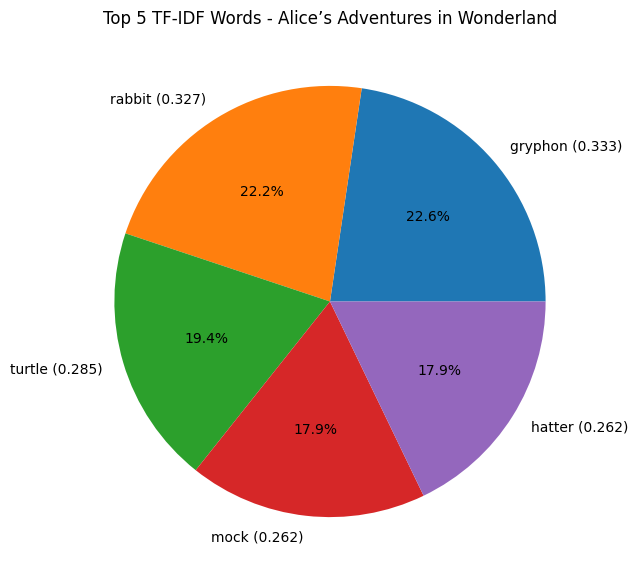

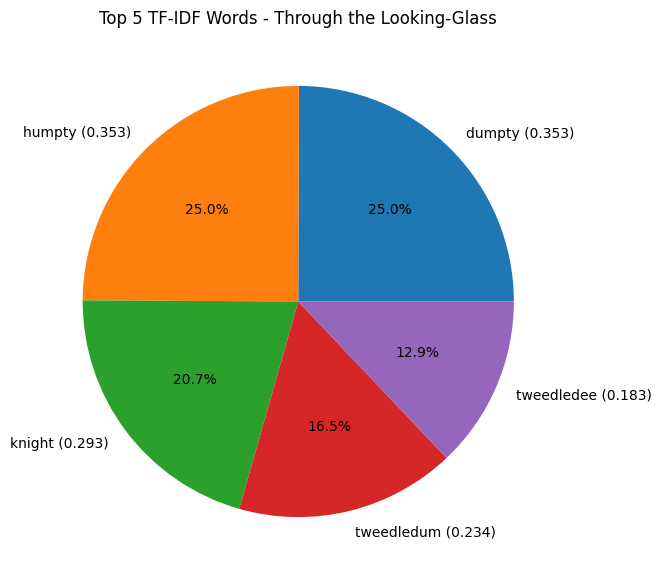

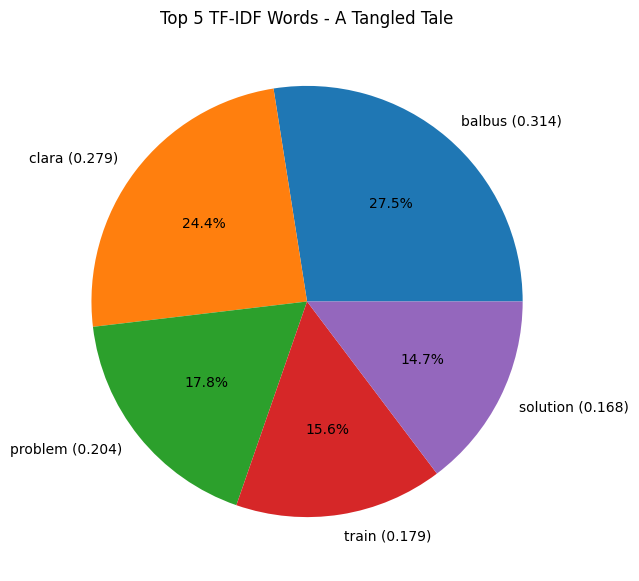

In [36]:
# Pie plots for top 5 TF-IDF words
for title in book_titles:
    top_5_tfidf = tfidf_df.loc[title].sort_values(ascending=False).head(5)

    labels = [f"{word} ({score:.3f})" for word, score in top_5_tfidf.items()]

    plt.figure(figsize=(7, 7))
    plt.pie(top_5_tfidf.values, labels=labels, autopct="%1.1f%%")
    plt.title(f"Top 5 TF-IDF Words - {title}")
    plt.show()

**Observation**: The TF-IDF results are more useful for comparison than the simple BoW results.

BoW gives high scores to words that appear frequently, even if those words are common across multiple books. For example, character names or common narrative verbs may dominate the frequency list.

TF-IDF gives more importance to words that are frequent in one document but less common in the other documents. Therefore, it helps identify words that are more distinctive to each book.

In this corpus, TF-IDF is useful because the three books are by the same author and share some vocabulary and style. Simple frequency shows repetition, while TF-IDF is better for finding what distinguishes one book from the others.